Lista de Exercícios IX - Complexidade, Algoritmos de Busca e Memoização.

Natã Batista Fernandes - RA: 24787400

Ex1

In [8]:
def gerar_combinacoes(n):
    combinacoes = []

    for i in range(2 ** n):
        combinacao = ""
        for j in range(n - 1, -1, -1):
            if i & (1 << j):
                combinacao += "1"
            else:
                combinacao += "0"
        combinacoes.append(combinacao)

    return combinacoes

resultado = gerar_combinacoes(3)
for c in resultado:
    print(c)

000
001
010
011
100
101
110
111


Ex2

In [9]:
def busca_sequencial(lista, chave):
    posicoes = []
    for i in range(len(lista)):
        if lista[i] == chave:
            posicoes.append(i)
    return posicoes

In [10]:
def busca_binaria(lista, chave):
    inicio = 0
    fim = len(lista) - 1
    achou = -1

    while inicio <= fim:
        meio = (inicio + fim) // 2
        if lista[meio] == chave:
            achou = meio
            break
        elif lista[meio] < chave:
            inicio = meio + 1
        else:
            fim = meio - 1

    if achou == -1:
        return []

    esq = achou
    while esq > 0 and lista[esq - 1] == chave:
        esq -= 1

    dir = achou
    while dir < len(lista) - 1 and lista[dir + 1] == chave:
        dir += 1

    return list(range(esq, dir + 1))


lista = [1, 2, 2, 3, 4, 4, 4, 5, 6]

for chave in [4, 2, 7]:
    print(f"chave {chave} -> sequencial: {busca_sequencial(lista, chave)} | binária: {busca_binaria(lista, chave)}")

chave 4 -> sequencial: [4, 5, 6] | binária: [4, 5, 6]
chave 2 -> sequencial: [1, 2] | binária: [1, 2]
chave 7 -> sequencial: [] | binária: []


Ex3

In [11]:
import time
import matplotlib.pyplot as plt


In [12]:
def fib_loop(n):
    if n <= 1:
        return n
    a, b = 0, 1
    for i in range(2, n + 1):
        a, b = b, a + b
    return b


def fib_rec(n):
    if n <= 1:
        return n
    return fib_rec(n - 1) + fib_rec(n - 2)


cache = {}
def fib_memo(n):
    if n <= 1:
        return n
    if n not in cache:
        cache[n] = fib_memo(n - 1) + fib_memo(n - 2)
    return cache[n]


ns = [5, 10, 15, 20, 25, 30, 35]
t_loop, t_rec, t_memo = [], [], []

for n in ns:
    cache.clear()

    t = time.perf_counter()
    fib_loop(n)
    t_loop.append((time.perf_counter() - t) * 1e6)

    t = time.perf_counter()
    fib_rec(n)
    t_rec.append((time.perf_counter() - t) * 1e6)

    cache.clear()
    t = time.perf_counter()
    fib_memo(n)
    t_memo.append((time.perf_counter() - t) * 1e6)

   n |       loop |          rec |       memo
   5 |     4.8740 |       3.1820 |     3.7240
  10 |     1.9370 |      11.7700 |     3.1800
  15 |     1.8520 |     117.3530 |     4.6880
  20 |     1.5050 |    1339.0480 |     6.6760
  25 |     2.2960 |   17411.5410 |    18.9470
  30 |     6.4140 |  184204.1240 |    22.3500
  35 |    10.1050 | 2701370.7560 |    34.5030


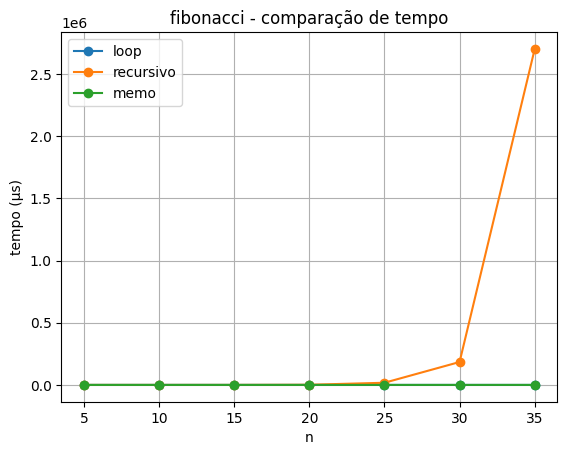

In [13]:
print(f"{'n':>4} | {'loop':>10} | {'rec':>12} | {'memo':>10}")
for i, n in enumerate(ns):
    print(f"{n:>4} | {t_loop[i]:>10.4f} | {t_rec[i]:>12.4f} | {t_memo[i]:>10.4f}")

plt.plot(ns, t_loop, marker='o', label='loop')
plt.plot(ns, t_rec, marker='o', label='recursivo')
plt.plot(ns, t_memo, marker='o', label='memo')
plt.xlabel('n')
plt.ylabel('tempo (µs)')
plt.title('fibonacci - comparação de tempo')
plt.legend()
plt.grid(True)
plt.show()